<a href="https://colab.research.google.com/github/rirfan3689/CSCI323-Spam-Detection/blob/main/notebooks/07_evaluation_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

uploaded = files.upload()  # Upload nb_results.json, lr_results.json, svm_results.json, rf_results.json

# Load all results
with open('nb_results.json') as f:
    nb_results = json.load(f)
with open('lr_results.json') as f:
    lr_results = json.load(f)
with open('svm_results.json') as f:
    svm_results = json.load(f)
with open('rf_results.json') as f:
    rf_results = json.load(f)

print("Results loaded successfully!")

Saving lr_results.json to lr_results.json
Saving nb_results.json to nb_results.json
Saving rf_results.json to rf_results.json
Saving svm_results.json to svm_results.json
Results loaded successfully!


In [ ]:
results = [nb_results, lr_results, svm_results, rf_results]
df_results = pd.DataFrame(results)
df_results = df_results.set_index('model')
df_results = df_results.round(4)

print("=== Model Comparison Table ===")
print(df_results)

=== Model Comparison Table ===
                     accuracy  precision  recall      f1
model                                                   
Naive Bayes            0.9681     1.0000  0.7481  0.8559
Logistic Regression    0.9536     0.9770  0.6489  0.7798
SVM                    0.9758     0.9569  0.8473  0.8988
Random Forest          0.9729     0.9725  0.8092  0.8833


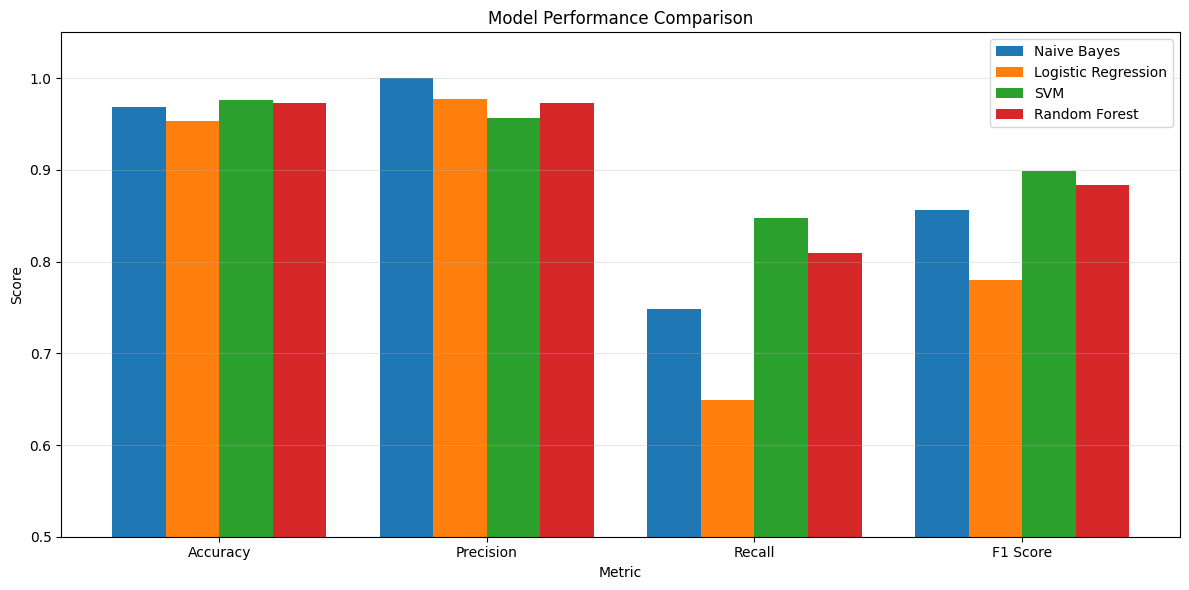

In [ ]:
metrics = ['accuracy', 'precision', 'recall', 'f1']
models = df_results.index.tolist()

x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

for i, model in enumerate(models):
    values = [df_results.loc[model, m] for m in metrics]
    ax.bar(x + i * width, values, width, label=model)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1 Score'])
ax.set_ylim(0.5, 1.05)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

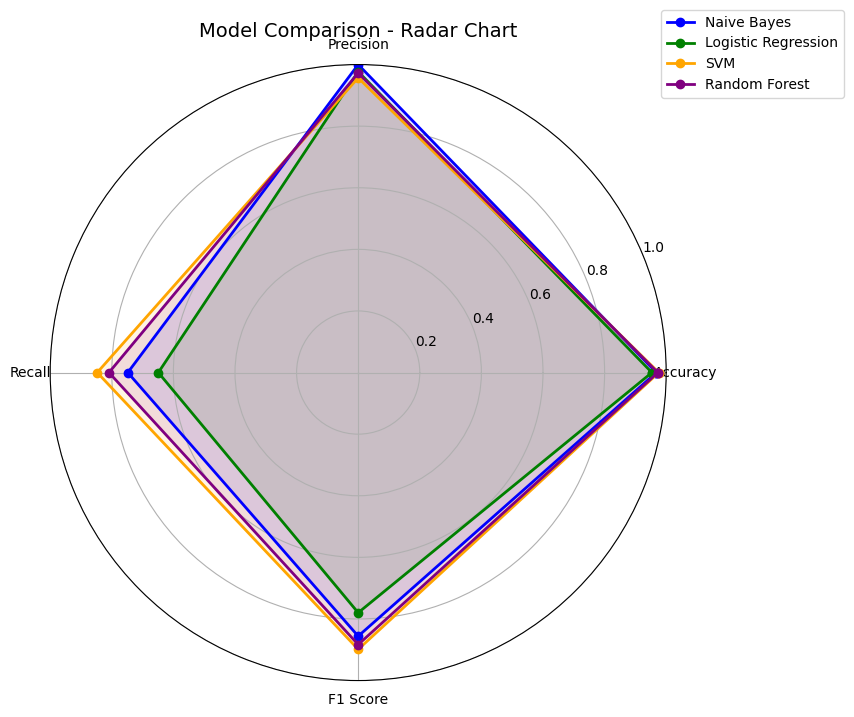

In [ ]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ['blue', 'green', 'orange', 'purple']

for i, (_, row) in enumerate(df_results.iterrows()):
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=df_results.index[i], color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Model Comparison - Radar Chart', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.savefig('radar_chart.png')
plt.show()

In [ ]:
print("=== FINAL SUMMARY ===\n")
print("Best Accuracy:  ", df_results['accuracy'].idxmax(), f"({df_results['accuracy'].max():.4f})")
print("Best Precision: ", df_results['precision'].idxmax(), f"({df_results['precision'].max():.4f})")
print("Best Recall:    ", df_results['recall'].idxmax(), f"({df_results['recall'].max():.4f})")
print("Best F1 Score:  ", df_results['f1'].idxmax(), f"({df_results['f1'].max():.4f})")
print("\nOverall Recommendation:")
print("SVM is the best overall model for spam detection based on F1 Score and Recall.")

=== FINAL SUMMARY ===

Best Accuracy:   SVM (0.9758)
Best Precision:  Naive Bayes (1.0000)
Best Recall:     SVM (0.8473)
Best F1 Score:   SVM (0.8988)

Overall Recommendation:
SVM is the best overall model for spam detection based on F1 Score and Recall.
